# Benchmark of Feature Selectors
This notebook benchmarks all scikit-learn feature selectors alongside the custom `pBGSK` algorithm against the datasets listed in `DATASET_REGISTRY`.


In [1]:
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(os.path.abspath('../src'))

from utils.data_importer import DATASET_REGISTRY, data_loader
from utils.pBGSK import feature_selection

from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    SelectPercentile, SelectFpr, SelectFdr, SelectFwe,
    GenericUnivariateSelect, RFE, SelectFromModel, SequentialFeatureSelector
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [2]:
def get_sklearn_selectors(n_features):
    """Return a dictionary of instantiated sklearn feature selectors."""
    k_val = max(1, n_features // 2)
    perc_val = 50
    est = RandomForestClassifier(n_estimators=5, random_state=42)
    
    return {
        "SelectKBest (f_classif)": SelectKBest(score_func=f_classif, k=k_val),
        "SelectKBest (mutual_info)": SelectKBest(score_func=mutual_info_classif, k=k_val),
        "SelectPercentile (f_classif)": SelectPercentile(score_func=f_classif, percentile=perc_val),
        "SelectFpr (f_classif)": SelectFpr(score_func=f_classif, alpha=0.05),
        "SelectFdr (f_classif)": SelectFdr(score_func=f_classif, alpha=0.05),
        "SelectFwe (f_classif)": SelectFwe(score_func=f_classif, alpha=0.05),
        "RFE (RF)": RFE(estimator=est, n_features_to_select=k_val),
        "SelectFromModel (RF)": SelectFromModel(estimator=est),
        "SFS Forward (RF)": SequentialFeatureSelector(est, n_features_to_select=k_val, direction='forward', cv=2),
        "SFS Backward (RF)": SequentialFeatureSelector(est, n_features_to_select=k_val, direction='backward', cv=2)
    }


In [3]:
results = []
geng_data_list = []
knn = KNeighborsClassifier(n_neighbors=5)

for dataset_name, dataset_id in DATASET_REGISTRY.items():
    print(f"\n{'='*50}\nProcessing dataset: {dataset_name} (ID: {dataset_id})\n{'='*50}")
    
    try:
        # Load dataset
        dataset = data_loader(dataset_name)
        if dataset is None or not hasattr(dataset, 'data'):
            print(f"Skipping {dataset_name} - could not load.")
            continue
            
        X = dataset.data.features
        y = dataset.data.targets
        
        # Limit to a maximum of 50,000 instances
        if X is not None and len(X) > 50000:
            print(f"  [!] Limiting dataset from {len(X)} to 50000 instances.")
            X = X[:50000]
            y = y[:50000]
        
        # Preprocessing X
        if X is None or X.empty:
            print(f"Skipping {dataset_name} - empty features.")
            continue
            
        X = X.fillna(X.mean(numeric_only=True))
        X = pd.get_dummies(X, drop_first=True)
        X = X.fillna(0)  # Any remaining NaNs
        
        # Preprocessing y
        if y is None or y.empty:
             print(f"Skipping {dataset_name} - empty targets.")
             continue
             
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]
            
        if y.dtype == 'object' or y.dtype.name == 'category':
            y = LabelEncoder().fit_transform(y)
            
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        n_features = X_train_scaled.shape[1]
        print(f"Total features: {n_features}, Samples: {X_train_scaled.shape[0]}")
        
        # 1. Base Model (All features)
        start_time = time.time()
        knn.fit(X_train_scaled, y_train)
        acc_base = accuracy_score(y_test, knn.predict(X_test_scaled))
        time_taken = time.time() - start_time
        
        results.append({
            "Dataset": dataset_name,
            "Method": "Base (All Features)",
            "Accuracy": acc_base,
            "Num_Features": n_features,
            "Time_s": time_taken
        })
        print(f"  [+] Base Model Acc: {acc_base:.4f} | Features: {n_features}")
        
        # 2. Sklearn Selectors
        selectors = get_sklearn_selectors(n_features)
        
        for sel_name, selector in selectors.items():
            start_time = time.time()
            try:
                X_train_sel = selector.fit_transform(X_train_scaled, y_train)
                X_test_sel = selector.transform(X_test_scaled)
                
                knn.fit(X_train_sel, y_train)
                preds = knn.predict(X_test_sel)
                acc = accuracy_score(y_test, preds)
                n_selected = X_train_sel.shape[1]
                
            except Exception as e:
                print(f"  [-] Error with {sel_name}: {e}")
                acc = np.nan
                n_selected = np.nan
                
            time_taken = time.time() - start_time
            results.append({
                "Dataset": dataset_name,
                "Method": sel_name,
                "Accuracy": acc,
                "Num_Features": n_selected,
                "Time_s": time_taken
            })
            print(f"  [+] {sel_name} Acc: {acc:.4f} | Features: {n_selected}")
            
        # 3. pBGSK Custom Selector
        start_time = time.time()
        try:
            # pBGSK requires DataFrames/Series with column names for indexing
            X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
            X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
            y_train_series = pd.Series(y_train).reset_index(drop=True)
            y_test_series = pd.Series(y_test).reset_index(drop=True)
            
            data_tuple = (X_train_df, X_test_df, y_train_series, y_test_series)
            
            # Use max NFE 500 and a time limit of 180 seconds
            pop, best_features_mask, best_score = feature_selection(
                data_tuple=data_tuple,
                num_population=20,
                nfe_total=500,
                lower_k=max(1, n_features // 4),
                upper_k=max(1, n_features // 2),
                columns_names=list(X.columns),
                data_set_name=dataset_name,
                knn_val=5,
                time_limit=180.0
            )
            
            # Select features
            X_train_sel = X_train_df.loc[:, best_features_mask]
            X_test_sel = X_test_df.loc[:, best_features_mask]
            
            knn.fit(X_train_sel, y_train_series)
            preds = knn.predict(X_test_sel)
            acc = accuracy_score(y_test_series, preds)
            n_selected = np.sum(best_features_mask)
            
            # Save optimization tracking
            if not pop.geng_df.empty:
                df_track = pop.geng_df.copy()
                df_track['Dataset'] = dataset_name
                geng_data_list.append(df_track)
            
        except Exception as e:
            print(f"  [-] Error with pBGSK: {e}")
            acc = np.nan
            n_selected = np.nan
            
        time_taken = time.time() - start_time
        results.append({
            "Dataset": dataset_name,
            "Method": "pBGSK",
            "Accuracy": acc,
            "Num_Features": n_selected,
            "Time_s": time_taken
        })
        print(f"  [+] pBGSK Acc: {acc:.4f} | Features: {n_selected} | Time: {time_taken:.2f}s")
        
    except Exception as e:
        print(f"Fatal error processing {dataset_name}: {e}")




Processing dataset: tic_tac_toe_endgame (ID: 101)
Total features: 18, Samples: 670
  [+] Base Model Acc: 0.9965 | Features: 18
  [+] SelectKBest (f_classif) Acc: 0.7951 | Features: 9
  [+] SelectKBest (mutual_info) Acc: 0.7014 | Features: 9
  [+] SelectPercentile (f_classif) Acc: 0.7951 | Features: 9
  [+] SelectFpr (f_classif) Acc: 0.9618 | Features: 16
  [+] SelectFdr (f_classif) Acc: 0.9618 | Features: 16
  [+] SelectFwe (f_classif) Acc: 0.7569 | Features: 8
  [+] RFE (RF) Acc: 0.8576 | Features: 9
  [+] SelectFromModel (RF) Acc: 0.7465 | Features: 7
  [+] SFS Forward (RF) Acc: 0.8646 | Features: 9
  [+] SFS Backward (RF) Acc: 0.8646 | Features: 9
  [+] pBGSK Acc: 0.9375 | Features: 16 | Time: 5.42s

Processing dataset: heart_disease (ID: 45)
Total features: 13, Samples: 212
  [+] Base Model Acc: 0.5824 | Features: 13
  [+] SelectKBest (f_classif) Acc: 0.5824 | Features: 6
  [+] SelectKBest (mutual_info) Acc: 0.5824 | Features: 6
  [+] SelectPercentile (f_classif) Acc: 0.5824 | Fea

In [4]:
# Display Results DataFrame
results_df = pd.DataFrame(results)
display(results_df.head(20))


,Dataset,Method,Accuracy,Num_Features,Time_s
0,tic_tac_toe_endgame,Base (All Features),0.996528,18,1.843243
1,tic_tac_toe_endgame,SelectKBest (f_classif),0.795139,9,0.008405
2,tic_tac_toe_endgame,SelectKBest (mutual_info),0.701389,9,0.093830
3,tic_tac_toe_endgame,SelectPercentile (f_classif),0.795139,9,0.010199
4,tic_tac_toe_endgame,SelectFpr (f_classif),0.961806,16,0.017265
5,tic_tac_toe_endgame,SelectFdr (f_classif),0.961806,16,0.018868
6,tic_tac_toe_endgame,SelectFwe (f_classif),0.756944,8,0.009917
7,tic_tac_toe_endgame,RFE (RF),0.857639,9,0.141030
8,tic_tac_toe_endgame,SelectFromModel (RF),0.746528,7,0.019593
9,tic_tac_toe_endgame,SFS Forward (RF),0.864583,9,3.117030


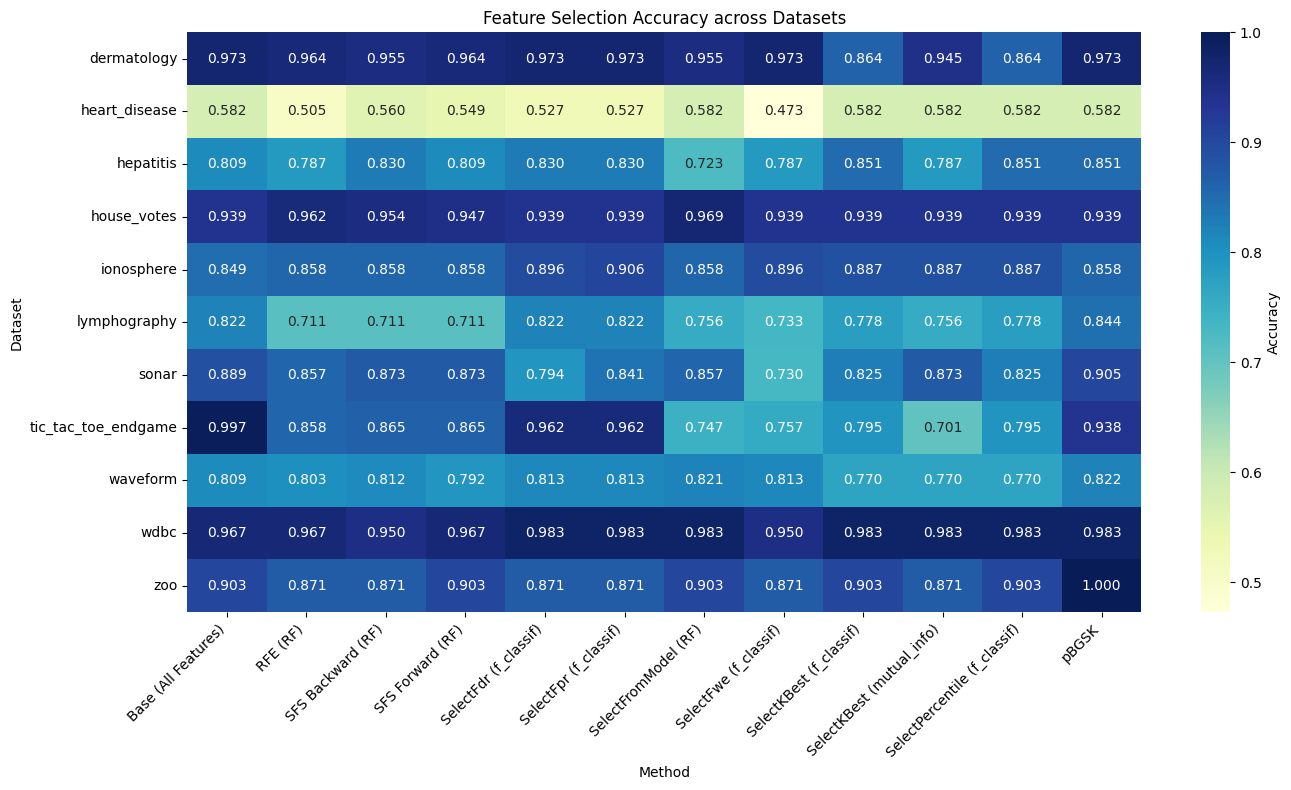

In [5]:
# Pivot tables for Comparison
# 1. Accuracy Comparison
acc_pivot = results_df.pivot(index='Dataset', columns='Method', values='Accuracy')

plt.figure(figsize=(14, 8))
sns.heatmap(acc_pivot, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': 'Accuracy'})
plt.title('Feature Selection Accuracy across Datasets')
plt.ylabel('Dataset')
plt.xlabel('Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


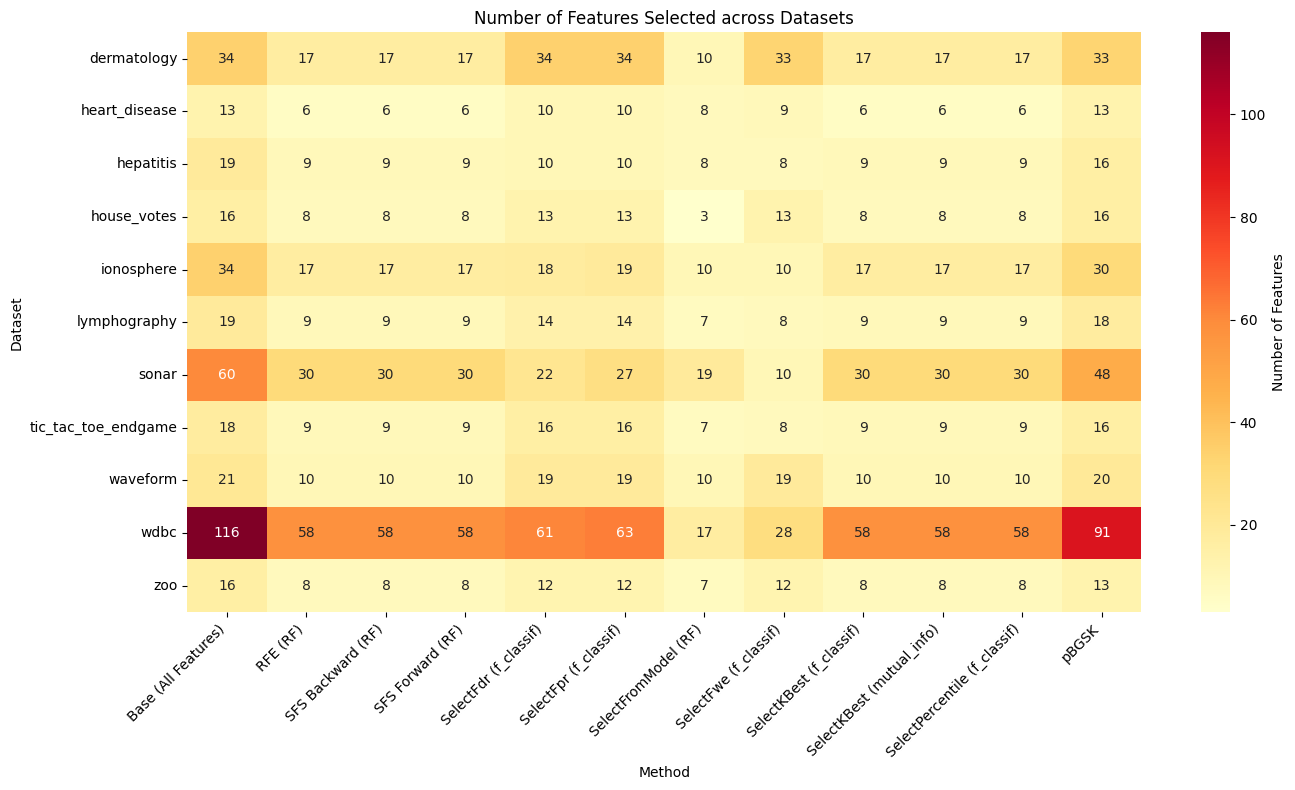

In [6]:
# 2. Number of Features Selected
feat_pivot = results_df.pivot(index='Dataset', columns='Method', values='Num_Features')

plt.figure(figsize=(14, 8))
sns.heatmap(feat_pivot, annot=True, cmap="YlOrRd", fmt=".0f", cbar_kws={'label': 'Number of Features'})
plt.title('Number of Features Selected across Datasets')
plt.ylabel('Dataset')
plt.xlabel('Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


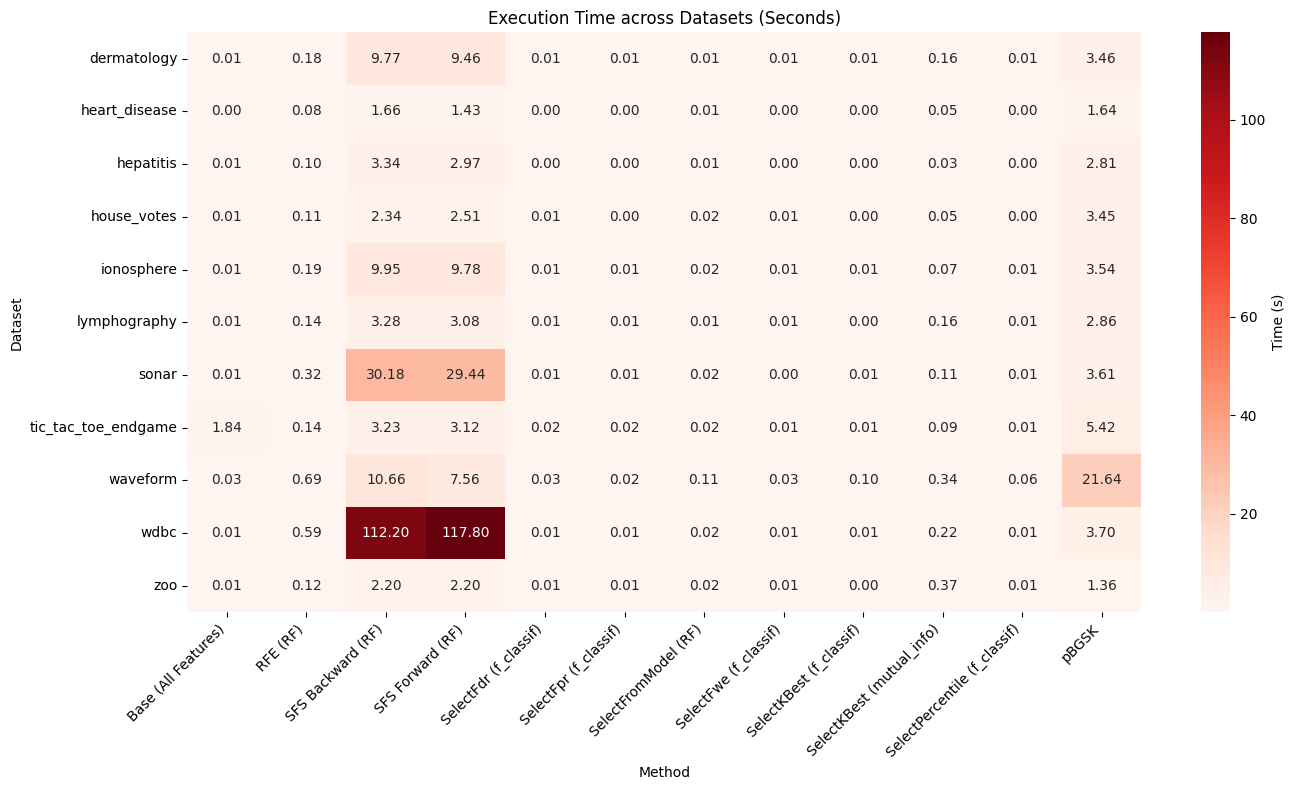

In [7]:
# 3. Execution Time Comparison
time_pivot = results_df.pivot(index='Dataset', columns='Method', values='Time_s')

plt.figure(figsize=(14, 8))
sns.heatmap(time_pivot, annot=True, cmap="Reds", fmt=".2f", cbar_kws={'label': 'Time (s)'})
plt.title('Execution Time across Datasets (Seconds)')
plt.ylabel('Dataset')
plt.xlabel('Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


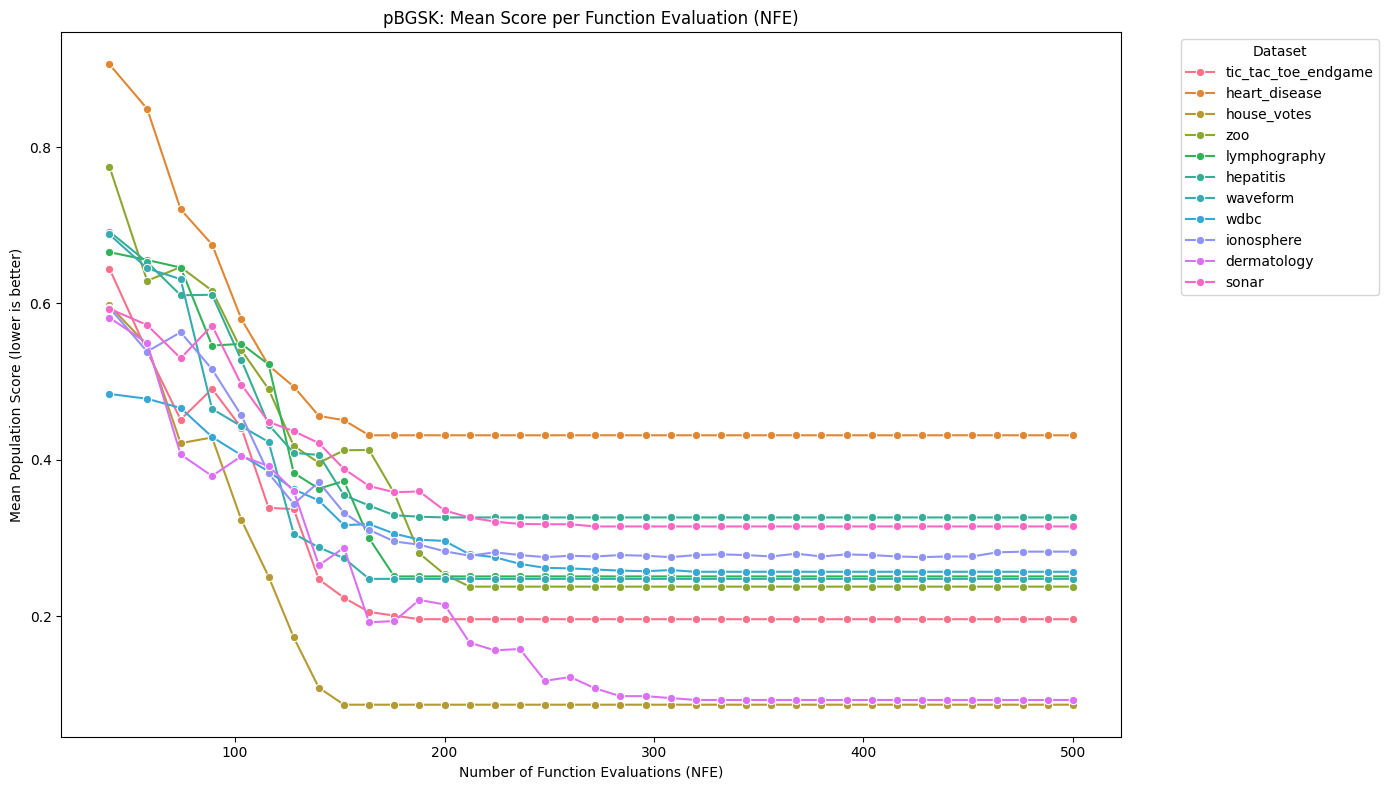

In [8]:
# 4. pBGSK Optimization Trace (Score per Function Evaluation)
if geng_data_list:
    geng_df_all = pd.concat(geng_data_list, ignore_index=True)
    
    plt.figure(figsize=(14, 8))
    sns.lineplot(data=geng_df_all, x='nfe', y='mean_score', hue='Dataset', marker='o')
    plt.title('pBGSK: Mean Score per Function Evaluation (NFE)')
    plt.xlabel('Number of Function Evaluations (NFE)')
    plt.ylabel('Mean Population Score (lower is better)')
    plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No pBGSK optimization data available to plot.")
